<a href="https://colab.research.google.com/github/parlankton/Purdue-Colab-Hyobin-Park/blob/main/L3_Colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/purduelamm/intro_micro_iiot/blob/main/lab/lab3/L3_Colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3.3 IO-Link data collection using JSON interface

## 3.1 Python programming for data collection from IO-Link master

The entire schematic of the data communication using JSON interface using REST API for the IO-Link vibraton device from the IO-Link master is illustrated in Figure 15. As the power meter data collection, your computers (laptop and Raspberry Pi) are on the router network. The IO-Link master is also on the same router network with a static IP address. The ethernet cable (RJ45) is used for connection between the router and the IO-Link master. Note that the IO-Link vibration sensor is connected to the **port 1** of the master. In this case using REST API, each of your computer is not a master but client. The IO-Link master is a server. The data communication sequence to read data from the IO-Link master is summarized as follows.

1.  The computer (Raspberry Pi or laptop) requests data using REST API's post method to the IO-Link master
2.  The IO-Link master read the IO-Link sensor data by the IO-Link protocol
3.  The IO-Link master sends back the received data from the IO-Link sensor to the computer as the JSON format.
4.  The computer receives the JSON data and parse it.

To do this, we will use Python and 'requests' and 'json' packages which are the basic packages in Python. Moreover, refer to details of JSON interface of the IFM IO-Link master [here](https://github.com/purduelamm/intro_micro_iiot/blob/main/lab/lab3/IFM_JSON_Integration_for_IO-Link.pdf?raw=true). The IO-Link vibration sensor (VVB001) manual for interface is also available [here](https://github.com/purduelamm/intro_micro_iiot/blob/main/lab/lab3/IFM_VVB001_IO-Link_Interface_Description.pdf?raw=true). **Please note that this lab manual skips all details to extract data for your convenience. If you perform data collection from other IoT devices, the first thing you have to do is to read the manual and figure out data communication protocols and take appropriate action.**


<img src="https://github.com/purduelamm/intro_micro_iiot/blob/main/lab/img/lab3_fig15.png?raw=true" width="90%">


*Figure 15 Schematic of communication for IO-Link data collection using JSON interface*

In this lab, the physical IO-Link master and sensor are replaced by a local IO-Link REST API emulator. Before running the data collection code, execute `lab3_IOlink_emulator.py` in a separate terminal:

**<img src="https://github.com/purduelamm/intro_micro_iiot/blob/main/lab/img/icon_Python.png?raw=true" width="20"> Python - Python 3 ([lab3_IOlink_emulator.py](https://github.com/purduelamm/intro_micro_iiot/blob/main/lab/lab3/lab3_IOlink_emulator.py?raw=true))**

```bash
python lab3_IOlink_emulator.py
```

This script works as a virtual IO-Link master. It receives HTTP POST requests from the Python client and returns simulated IO-Link sensor data in JSON format. The returned data structure follows the same format as the actual IO-Link master REST API response, including the raw hexadecimal sensor value.

Since the emulator runs on the same computer, set the URL in the client code as:

```python
URL = "http://127.0.0.1:80"
```

After starting the emulator, keep the terminal open while running the client program. If the emulator is stopped, the client program will not be able to connect to the virtual IO-Link master.

What you need to do first to use TCP/IP communication and the REST API is to check the connection between your computer and the IO-Link master or emulator. In general, you can use a ping test to check basic network connectivity.

Please note that in some network configurations, such as VPN, firewall-restricted networks, or port forwarding, the ping test may fail even when the REST API server is available. In this case, check whether the HTTP port used by the IO-Link master or emulator is reachable.



### Task 3.1

Capture the results of checking network connection using ping test from both Raspberry Pi and laptop to the IO-Link master for REST API as Task 2.1 on ([Lab3.2](https://githubtocolab.com/purduelamm/intro_micro_iiot/blob/main/lab/lab3/L3_Colab2.ipynb)) and attach it to the report.
*  Please note that the IP address of the IO-Link master will be different from the example.




---

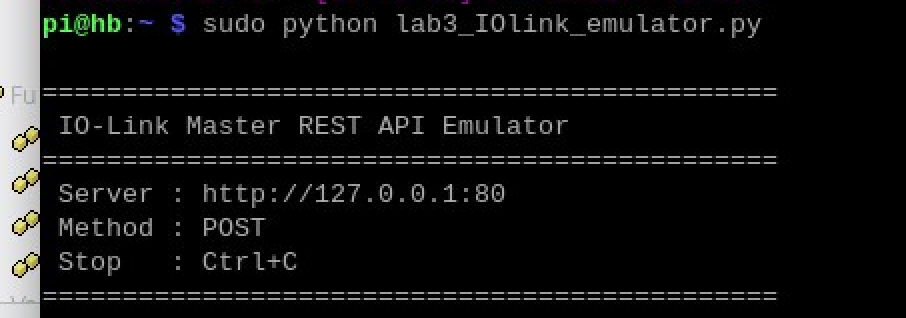
---





---

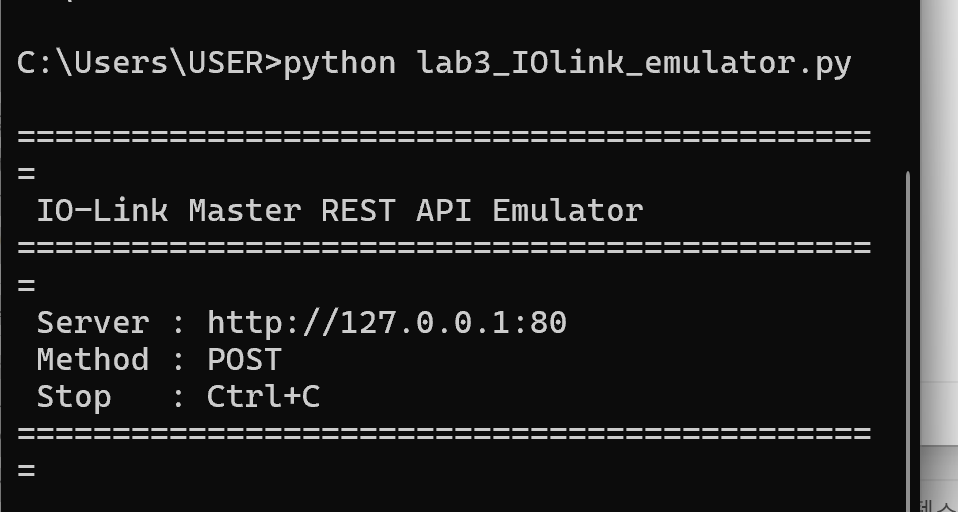

---



If ping test works, you are ready to request data. Before we request data to the IO-Link master, let's see what data is available from the sensor. The selected available data is shown in Table 4. These information is also available on the manual [here](https://github.com/Eunseob/purdue_me597/blob/main/lab/lab3/IFM_VVB001_IO-Link_Interface_Description.pdf?raw=true) on page 9. Other than data from Table 4, tens of more data are available. In this lab, we will collect the selected data only. The refresh rate of the sensor is approximately 200 msec in default setting.

**Note that to take an appropriate value with unit, a multiplier in the Range column of Table 4 must be applied after receiving data. For example, after multiplying 0.0001 to v-Rms value, the measured data has unit of m/s.**

*Table 4 Selected process data from VVB001 sensor*

<table width="100%">
<thead>
  <tr>
    <th>Process data input</th>
    <th>Description</th>
    <th>Record Type</th>
    <th>Range</th>
    <th>Unit</th>
  </tr>
</thead>
<tbody>
  <tr>
    <td>v-Rms</td>
    <td>Speed effective value</td>
    <td rowspan="5">IntegerT (16 bit)</td>
    <td>(0 to 495)*0.0001</td>
    <td>m/s</td>
  </tr>
  <tr>
    <td>a-Peak</td>
    <td>Acceleration peak value</td>
    <td>(0 to 4903)*0.1</td>
    <td>m/s2</td>
  </tr>
  <tr>
    <td>a_Rms</td>
    <td>Acceleration effective value</td>
    <td>(0 to 4903)*0.1</td>
    <td>m/s2</td>
  </tr>
  <tr>
    <td>Temperature</td>
    <td>Current temperature</td>
    <td>(-300 to 800)*0.1</td>
    <td>°C</td>
  </tr>
  <tr>
    <td>Crest</td>
    <td>Acceleration crest factor</td>
    <td>(10 to 500)*0.1</td>
    <td>-</td>
  </tr>
</tbody>
</table>

---

**<img src="https://github.com/purduelamm/intro_micro_iiot/blob/main/lab/img/icon_Python.png?raw=tru" width="20">Python - Python 3 ([lab3_sample2.py](https://github.com/purduelamm/intro_micro_iiot/blob/main/lab/lab3/lab3_sample2.py?raw=true))**

```
import requests
import json
import datetime

# define the IO-Link master IP
URL = "http://127.0.0.1/"

# define JSON body for post method
# for the details, see the JSON interface manual
# note that the sensor is connected to port 1
BODY = {
        "code":"request",
        "cid":-1,
        "adr":"/iolinkmaster/port[1]/iolinkdevice/iolreadacyclic",
        "data":{"index":40,"subindex":0}    
}

now = datetime.datetime.now()

# this requests data to the IO-Link master
# using POST method of REST API with BODY information
# req object will be response from the IO-Link master
req = requests.post(url = URL, json=BODY)

data_json = req.json() # this is json format data of req

# because the the JSON data itself is in unformatted,
# dumps method of JSON module below helps us to see the data in JSON format
data_json_formatted = json.dumps(data_json, indent=2)

print(now, ': Data structure from the IO-Link master\n',data_json_formatted)

# parsing JSON:
# as you can see the above print,
# 'value' is accesible in 'data' of the JSON data
value = data_json['data']['value']

# the raw measured value looks like 0000FC000002FF000000FF0000F6FF000026FF03
# the length of the value is 40
# this is byte array in 16-bit integer format
print('raw measured value is', value)


# Always, the returned value type from JSON is string
# below is converting the value to v-Rms
# description of v_rms variable is that
# first, select first four elements from value
# second, convert them into 16-bit integer
# third, multiply 0.0001 to take the correct unit (m/s) and data
# finally, rounding up and the data type is float
v_rms = round(int(value[0:4], 16) * 0.0001)

print('v_Rms =', v_rms ,'m/s')

### indexing information is that
# a_Peak data = value[8:12]
# a_Rms data = value[16:20]
# Temperature data = value[24:28]
# Crest data = value[32:36]

```

---

The sample code 2 (lab3_sample2.py) is given as above. This code is to print out v_Rms. Go through the code and run it. Based on the given code, perform the Tasks below.

### Task 3.2

Modify the sample code 2 on both laptop and Raspberry Pi to print out all data (v_Rms, a_Peak, a_Rms, Temperature, and Crest) as Table 4.

* Print the values with units in Table 4




---

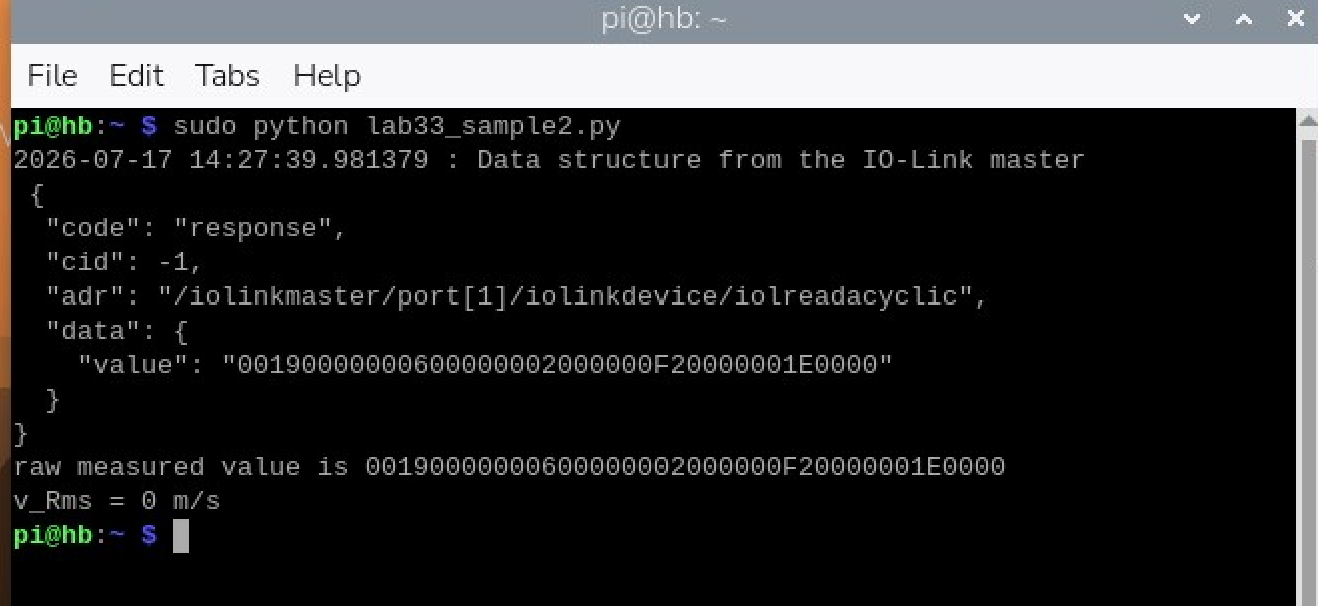
---





---

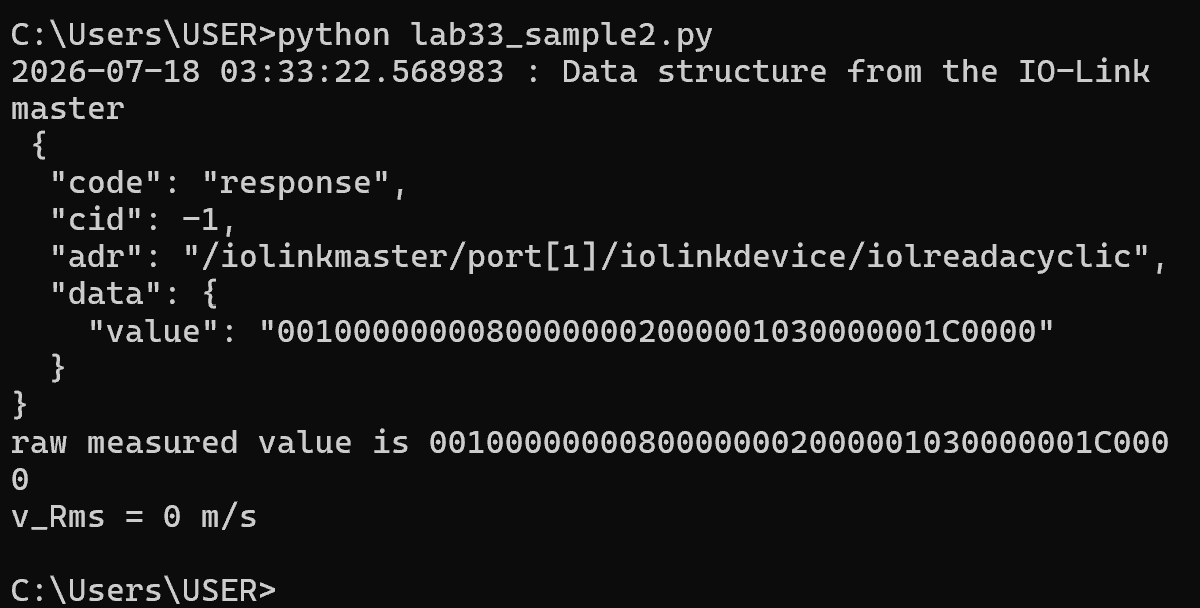

---



### Task 3.3

1.	Perform the same as Task 2.3; Modify sample code 2 to collect IO-Link data for at least 1 minute and save data as a CSV file.

* You can use one computer either laptop or Raspberry Pi.
* Set the sampling period 1 second.
* Data (header) should include time or datetime, v_Rms, a_Peak, a_Rms, Temperature, Crest as Table 5.
* As a practice, plot data and calculate time-domain features.

*Table 5 Example data of output CSV file for Task 3.3*
<table width="100%">
<thead>
  <tr>
    <th>Time [sec]</th>
    <th>v_Rms [m/s]</th>
    <th>a_Peak [m/s2]</th>
    <th>a_Rms [m/s2]</th>
    <th>Temperature [C]</th>
    <th>Crest [-]</th>
  </tr>
</thead>
<tbody>
  <tr>
    <td colspan="6" align="center">...</td>
  </tr>
  <tr>
    <td>10.254</td>
    <td>0.001</td>
    <td>1.24</td>
    <td>0.48</td>
    <td>24.1</td>
    <td>2.58</td>
  </tr>
  <tr>
    <td>10.461</td>
    <td>0.002</td>
    <td>1.34</td>
    <td>0.51</td>
    <td>23.9</td>
    <td>2.63</td>
  </tr>
  <tr>
    <td colspan="6" align="center">...</td>
  </tr>
</tbody>
</table>

## 3.2 Data collection from multiple sensors in a single program

In this lab so far, we collected data from each sensor in a program. In this section, we try to collect data from both sensors at the same time in a single program.

Perform the Tasks below.

셀이 날라갔는데 복구가 안되는 것 같아 여기 뒤에 이어서 코드 작성하겠습니다.

Saving task3_3_data.csv to task3_3_data.csv
행 개수: 60
컬럼명: ['Time [sec]', 'v_Rms [m/s]', 'a_Peak [m/s2]', 'a_Rms [m/s2]', 'Temperature [C]', 'Crest [-]']
   Time [sec]  v_Rms [m/s]  a_Peak [m/s2]  a_Rms [m/s2]  Temperature [C]  \
0       0.000       0.0023            0.7           0.3             25.2   
1       1.011       0.0016            0.8           0.4             25.6   
2       2.021       0.0022            0.8           0.4             24.1   
3       3.030       0.0015            1.0           0.3             24.5   
4       4.041       0.0019            0.9           0.2             24.2   
5       5.051       0.0024            0.7           0.2             25.0   
6       6.068       0.0018            0.9           0.3             24.7   
7       7.081       0.0024            0.8           0.3             25.8   
8       8.090       0.0019            0.9           0.4             24.4   
9       9.101       0.0019            0.7           0.2             25.2   

   Crest [

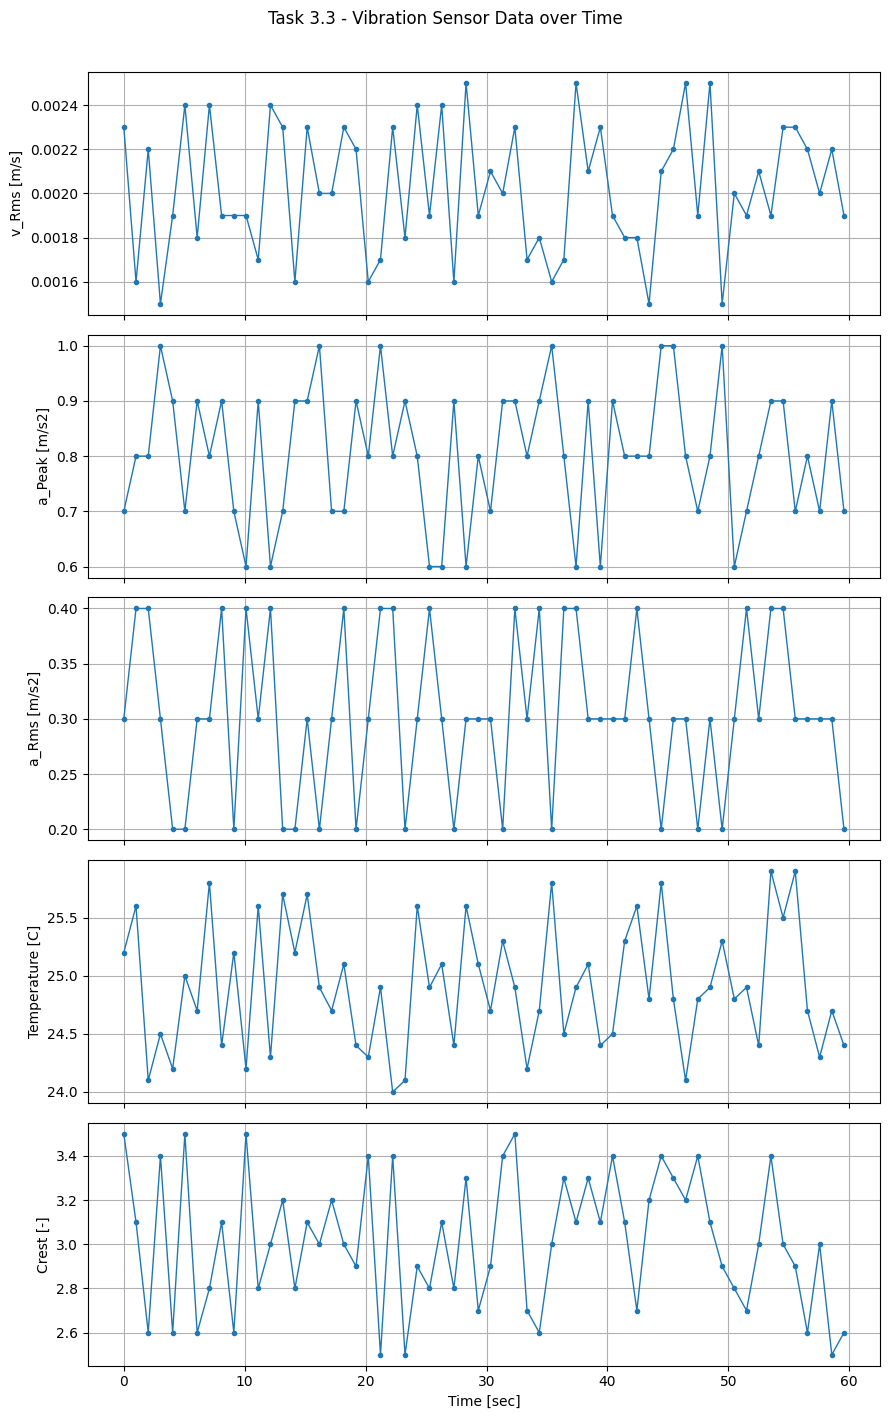


[v_Rms [m/s]]
  Mean  = 0.0020
  Std   = 0.0003
  RMS   = 0.0020
  Peak  = 0.0025
  Crest Factor = 1.2241

[a_Peak [m/s2]]
  Mean  = 0.8050
  Std   = 0.1227
  RMS   = 0.8141
  Peak  = 1.0000
  Crest Factor = 1.2283

[a_Rms [m/s2]]
  Mean  = 0.3033
  Std   = 0.0736
  RMS   = 0.3120
  Peak  = 0.4000
  Crest Factor = 1.2821

[Temperature [C]]
  Mean  = 24.9067
  Std   = 0.5364
  RMS   = 24.9123
  Peak  = 25.9000
  Crest Factor = 1.0396

[Crest [-]]
  Mean  = 3.0133
  Std   = 0.3022
  RMS   = 3.0282
  Peak  = 3.5000
  Crest Factor = 1.1558


In [3]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv("task3_3_data.csv")

print("행 개수:", len(df))
print("컬럼명:", df.columns.tolist())
print(df.head(10))
print("\n각 컬럼 통계 요약:")
print(df.describe())

import matplotlib.pyplot as plt

cols = df.columns[1:]  # Time 제외한 5개 컬럼

fig, axs = plt.subplots(len(cols), 1, figsize=(9, 14), sharex=True)

for ax, col in zip(axs, cols):
    ax.plot(df["Time [sec]"], df[col], marker='o', markersize=3, linewidth=1)
    ax.set_ylabel(col)
    ax.grid(True)

axs[-1].set_xlabel("Time [sec]")
plt.suptitle("Task 3.3 - Vibration Sensor Data over Time", y=1.01)
plt.tight_layout()
plt.show()
import numpy as np

for col in cols:
    x = df[col]
    mean_val = x.mean()
    std_val = x.std()
    rms_val = np.sqrt(np.mean(x**2))
    peak_val = x.max()
    crest_factor = peak_val / rms_val if rms_val != 0 else float('nan')

    print(f"\n[{col}]")
    print(f"  Mean  = {mean_val:.4f}")
    print(f"  Std   = {std_val:.4f}")
    print(f"  RMS   = {rms_val:.4f}")
    print(f"  Peak  = {peak_val:.4f}")
    print(f"  Crest Factor = {crest_factor:.4f}")


### Task 3.4

By using the sample code 1 and 2, program a Python code as instructed below.

* Make infinitely printing out all sensor data at the same time in a 'while' loop.
* Use 'try' and 'except' to halt your program when pressing Ctrl+c.
* Capture your console window or terminal when your program is running and attach it below.
* You can use either laptop or Raspberry Pi to run this code.




---

Place your screenshot for Task 3.4 here.

---



In [ ]:
from google.colab import files
import pandas as pd
import time

# Upload CSV file
uploaded = files.upload()

# Read the uploaded CSV file
df = pd.read_csv("task3_3_data.csv")

# Display the number of rows and column names
print("Number of rows:", len(df))
print("Column names:", df.columns.tolist())

print("\nSensor data:")
print(df.to_string(index=False))

print("\nPress Ctrl+C to stop the program.\n")

try:
    # Infinitely print all sensor data
    while True:
        print(df.to_string(index=False))

        # Wait before printing again
        time.sleep(1)

except KeyboardInterrupt:
    print("\nProgram stopped by user.")

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
      1.011       0.0016            0.8           0.4             25.6        3.1
      2.021       0.0022            0.8           0.4             24.1        2.6
      3.030       0.0015            1.0           0.3             24.5        3.4
      4.041       0.0019            0.9           0.2             24.2        2.6
      5.051       0.0024            0.7           0.2             25.0        3.5
      6.068       0.0018            0.9           0.3             24.7        2.6
      7.081       0.0024            0.8           0.3             25.8        2.8
      8.090       0.0019            0.9           0.4             24.4        3.1
      9.101       0.0019            0.7           0.2             25.2        2.6
     10.109       0.0019            0.6           0.4             24.2        3.5
     11.118       0.0017            0.9           0.3             25.6        2.8
     12.130       0.0024            0.6           0.4         

In [4]:
import requests
import json
import datetime
import time
import pandas as pd

# define the IO-Link master IP
URL = "http://127.0.0.1/"

# define JSON body for post method
# for the details, see the JSON interface manual
# note that the sensor is connected to port 1
BODY = {
        "code":"request",
        "cid":-1,
        "adr":"/iolinkmaster/port[1]/iolinkdevice/iolreadacyclic",
        "data":{"index":40,"subindex":0}
}

print("Collecting sensor data... Press Ctrl+C to stop and save data.")

data_records = []
start_time = time.time() # Record the start time

try:
    # 센서 데이터를 무한히 수집 및 출력
    while True:
        current_time = time.time() # Get current time
        elapsed_time = round(current_time - start_time, 3) # Calculate elapsed time

        # this requests data to the IO-Link master
        # using POST method of REST API with BODY information
        req = requests.post(url = URL, json=BODY)
        data_json = req.json() # this is json format data of req

        # parsing JSON: 'value' is accessible in 'data' of the JSON data
        value = data_json['data']['value']

        # Always, the returned value type from JSON is string
        # below is converting the value to all sensor data
        v_rms = round(int(value[0:4], 16) * 0.0001, 4)
        a_peak = round(int(value[8:12], 16) * 0.1, 2)
        a_rms = round(int(value[16:20], 16) * 0.1, 2)
        temperature = round(int(value[24:28], 16) * 0.1, 1)
        crest = round(int(value[32:36], 16) * 0.1, 2)

        print(f"{datetime.datetime.now()}: ", end="")
        print(f"v_Rms = {v_rms} m/s | ", end="")
        print(f"a_Peak = {a_peak} m/s2 | ", end="")
        print(f"a_Rms = {a_rms} m/s2 | ", end="")
        print(f"Temperature = {temperature} C | ", end="")
        print(f"Crest = {crest} -")

        # Store data in a dictionary
        data_records.append({
            'Time [sec]': elapsed_time,
            'v_Rms [m/s]': v_rms,
            'a_Peak [m/s2]': a_peak,
            'a_Rms [m/s2]': a_rms,
            'Temperature [C]': temperature,
            'Crest [-]': crest
        })

        # Set sampling period to 1 second
        time.sleep(1)

except KeyboardInterrupt:
    print("\nProgram stopped by user. Saving data to CSV...")
except requests.exceptions.ConnectionError:
    print("\nConnection Error: Ensure the IO-Link emulator is running at http://127.0.0.1/.")
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")
finally:
    if data_records:
        df = pd.DataFrame(data_records)
        df.to_csv('sensor_data.csv', index=False)
        print("Data saved to sensor_data.csv")
    else:
        print("No data collected to save.")


Connection Error: Ensure the IO-Link emulator is running at http://127.0.0.1/.
No data collected to save.


### Task 3.5

Let's think more about IoT sensors and data collection in the sense of the programmer. The answers are open-ended. Answer the questions below.

#### 1) If you want to collect data from muliple sensors which have different sampling periods, how can you implement your program?



---

I can use a separate timer for each sensor. The program checks each timer in a while loop and collects data when the corresponding sampling period has elapsed.

---



#### 2) How can you make your program robust/stable even if suddenly unwanted network connection failure happens?








---

I can use error handling and automatic reconnection. If the network connection fails, the program can temporarily store the data locally and retry the connection until it is restored.

---



#### 3) What can you do with the electrical power and vibration data? Can they be used for an operational condition or health monitoring?





---

Electrical power and vibration data can be used for operational condition and health monitoring. Changes in power consumption or vibration patterns can indicate abnormal operation, wear, or potential machine failure, allowing predictive maintenance.

---



## Lab3 Summary and Deliverables

Answer the following questions for your achievements




### Q1. Please summarize Lab3.

---
I learned how to collect, process, and continuously monitor sensor data using Python, and how sensor data can be used for machine condition and health monitoring.

---


### Q2. What skills did you have to develop to accomplish this project?

---

I developed Python programming, data processing, sensor data collection, and troubleshooting skills to complete this project.

---

### Q3. What aspects of this project were the most beneficial for your learning?

---
The most beneficial aspect was learning how to collect and continuously monitor real sensor data using Python.

---

### Q4. What challenges did you encounter in completing the project?

---
The main challenge was handling the sensor data and making the program continuously run without errors.

---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

I overcame these challenges by debugging the code, checking the sensor data, and using try and except to handle errors and stop the program safely.

---

<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/intro_micro_iiot/blob/main/index.ipynb)